# Unit 1 code companion: Statistical Inference

Five short simulations behind the slides: what 'just guessing' looks like, where the standard error comes from, what p-values do under the null, what power buys you, and the two ways a t-test quietly lies to you.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. The Coke test: what 'just guessing' looks like

A guesser calling 10 cups is 10 coin flips. Before you can call a score impressive, you need the distribution of scores a guesser produces.

P(guesser gets >=  7 right) = 0.1719
P(guesser gets >=  8 right) = 0.0547
P(guesser gets >=  9 right) = 0.0107
P(guesser gets >= 10 right) = 0.0010


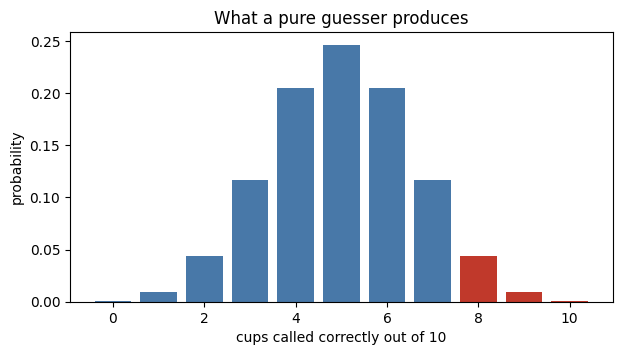

In [2]:
k = np.arange(0, 11)
pmf = stats.binom.pmf(k, 10, 0.5)

for cutoff in [7, 8, 9, 10]:
    print(f"P(guesser gets >= {cutoff:2d} right) = {stats.binom.sf(cutoff-1, 10, 0.5):.4f}")

plt.bar(k, pmf, color=["#c0392b" if v >= 8 else "#4878a8" for v in k])
plt.xlabel("cups called correctly out of 10"); plt.ylabel("probability")
plt.title("What a pure guesser produces"); plt.show()

**Try it:** change 10 cups to 20. How many must they get right for the result to be surprising at the same 5% level? Is it more or less than double?

## 2. Two tasters: how far apart can luck put them?

The gap between two guessers is the two-sample question in miniature.

In [3]:
sims = rng.binomial(10, 0.5, size=(200_000, 2))
gap = np.abs(sims[:, 0] - sims[:, 1])
for g in [3, 4, 5, 6]:
    print(f"P(gap >= {g}) = {(gap >= g).mean():.3f}")

P(gap >= 3) = 0.264
P(gap >= 4) = 0.115
P(gap >= 5) = 0.042
P(gap >= 6) = 0.012


## 3. Where the standard error comes from

Draw the same study over and over and watch the estimate move. The spread of those estimates *is* the standard error. The formula sigma/sqrt(n) only predicts it.

In [4]:
sigma = 12.0
for n in [10, 40, 160, 640]:
    means = rng.normal(50, sigma, size=(20_000, n)).mean(axis=1)
    print(f"n = {n:4d}   SD of the sample means = {means.std():5.2f}   "
          f"sigma/sqrt(n) = {sigma/np.sqrt(n):5.2f}")

n =   10   SD of the sample means =  3.83   sigma/sqrt(n) =  3.79
n =   40   SD of the sample means =  1.89   sigma/sqrt(n) =  1.90
n =  160   SD of the sample means =  0.94   sigma/sqrt(n) =  0.95


n =  640   SD of the sample means =  0.47   sigma/sqrt(n) =  0.47


Four times the data cuts the noise in half, not to a quarter. That square root is the entire economics of sample size, and it is why 'just collect more data' gets expensive fast.

## 4. What p-values do when nothing is going on

This is the single most clarifying simulation in the course. Run studies where the truth is *no difference at all*, and look at the p-values you get.

fraction of NULL studies with p < 0.05: 0.048  (should be ~0.05)


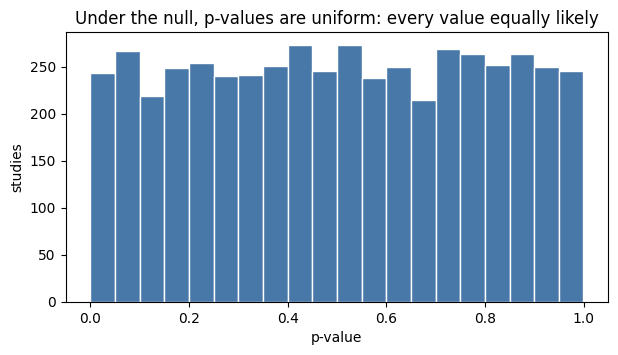

In [5]:
def run_studies(n_studies=5000, n=30, true_diff=0.0, sd=1.0):
    a = rng.normal(0, sd, size=(n_studies, n))
    b = rng.normal(true_diff, sd, size=(n_studies, n))
    return stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue

p_null = run_studies(true_diff=0.0)
print(f"fraction of NULL studies with p < 0.05: {(p_null < 0.05).mean():.3f}  (should be ~0.05)")

plt.hist(p_null, bins=20, color="#4878a8", edgecolor="white")
plt.xlabel("p-value"); plt.ylabel("studies")
plt.title("Under the null, p-values are uniform: every value equally likely"); plt.show()

Read that histogram carefully. When nothing is happening, a p-value below 0.05 is not rare or strange, it happens in exactly 5% of studies **by construction**. That is what the 5% means. It is a false-alarm rate you chose, not evidence you discovered.

## 5. Power: what happens when something *is* going on



In [6]:
print(f"{'true effect':>12} {'n':>5} {'power':>8}")
for eff in [0.2, 0.5, 0.8]:
    for n in [15, 30, 100]:
        power = (run_studies(n=n, true_diff=eff) < 0.05).mean()
        print(f"{eff:>12} {n:>5} {power:>8.2f}")

 true effect     n    power
         0.2    15     0.08
         0.2    30     0.12
         0.2   100     0.29
         0.5    15     0.27


         0.5    30     0.48


         0.5   100     0.94
         0.8    15     0.57
         0.8    30     0.87
         0.8   100     1.00


A real effect of 0.2 with n=15 is caught about 1 time in 10. If you run that study and get nothing, you have learned almost nothing about the world, only about your sample size.

## 6. The winner's curse

When power is low, the only results that reach significance are the ones that got lucky and large. So 'significant' effects come out systematically overstated.

In [7]:
n, true_effect = 15, 0.3
a = rng.normal(0, 1, size=(20_000, n))
b = rng.normal(true_effect, 1, size=(20_000, n))
res = stats.ttest_ind(a, b, axis=1, equal_var=False)
est = b.mean(axis=1) - a.mean(axis=1)
sig = res.pvalue < 0.05

print(f"true effect                       : {true_effect}")
print(f"average estimate, all studies     : {est.mean():.3f}")
print(f"average estimate, SIGNIFICANT only: {est[sig].mean():.3f}   <-- inflated {est[sig].mean()/true_effect:.1f}x")
print(f"power                             : {sig.mean():.2f}")

true effect                       : 0.3
average estimate, all studies     : 0.300
average estimate, SIGNIFICANT only: 0.846   <-- inflated 2.8x
power                             : 0.12


## 7. Two ways the t-test lies: peeking, and dependence



In [8]:
# (a) PEEKING: test repeatedly as data arrive, stop the moment p < 0.05.
def peek_experiment(max_n=500, checks=25):
    a = rng.normal(0, 1, max_n); b = rng.normal(0, 1, max_n)   # NO real difference
    for n in np.linspace(20, max_n, checks).astype(int):
        if stats.ttest_ind(a[:n], b[:n], equal_var=False).pvalue < 0.05:
            return True
    return False

false_alarms = np.mean([peek_experiment() for _ in range(2000)])
print(f"false-positive rate when you peek 25 times: {false_alarms:.3f}  (you asked for 0.05)")

false-positive rate when you peek 25 times: 0.263  (you asked for 0.05)


In [9]:
# (b) DEPENDENCE: 40 users, 50 sessions each. The rows are not independent.
n_users, per_user = 40, 50
user_effect = rng.normal(0, 1.0, size=(2, n_users, 1))          # each user has a personality
sessions = user_effect + rng.normal(0, 1.0, size=(2, n_users, per_user))

t_rows, p_rows = stats.ttest_ind(sessions[0].ravel(), sessions[1].ravel(), equal_var=False)
t_user, p_user = stats.ttest_ind(sessions[0].mean(axis=1), sessions[1].mean(axis=1), equal_var=False)
print(f"treating all {2*n_users*per_user} SESSIONS as independent: t = {t_rows:6.2f}, p = {p_rows:.4f}")
print(f"aggregating to {2*n_users} USERS (the real unit)        : t = {t_user:6.2f}, p = {p_user:.4f}")

treating all 4000 SESSIONS as independent: t =  -7.78, p = 0.0000
aggregating to 80 USERS (the real unit)        : t =  -1.57, p = 0.1204


Run that cell a few times. The session-level test is not just noisier, it is *wrong*: it reports far more confidence than the data contains, because 2,000 rows from 40 people is not 2,000 independent pieces of information.

## 7c. Two things the homework needs: group summaries and a picture

Every real comparison starts by describing the groups and looking at them, not by running a test.

            count   mean    std  median
Holiday                                
Holiday        18  621.6  587.3   306.0
No Holiday    347  703.5  421.8   714.0 

     Holiday: mean  621.6, median  306.0, gap +315.6
  No Holiday: mean  703.5, median  714.0, gap  -10.5


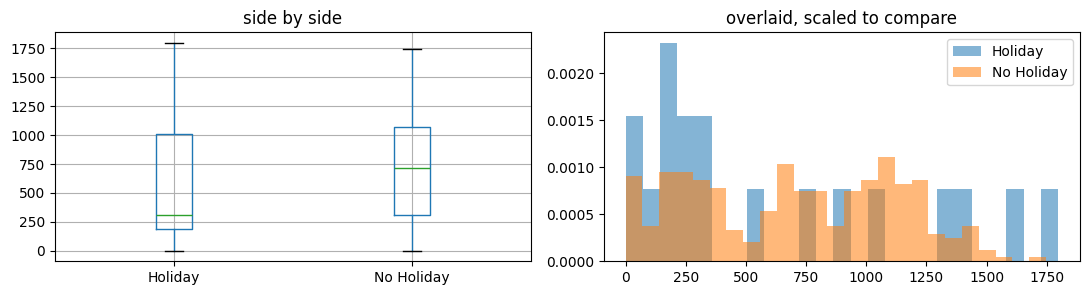

In [10]:
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")

# per-group summaries: count, mean, SD, median
summary = bikes.groupby("Holiday")["Count"].agg(["count", "mean", "std", "median"]).round(1)
print(summary, "\n")

# mean vs median is the quick skew check
for name, g in bikes.groupby("Holiday"):
    print(f"{name:>12}: mean {g.Count.mean():6.1f}, median {g.Count.median():6.1f}, "
          f"gap {g.Count.mean() - g.Count.median():+6.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
bikes.boxplot(column="Count", by="Holiday", ax=axes[0])
axes[0].set_title("side by side"); axes[0].set_xlabel(""); plt.suptitle("")
for name, g in bikes.groupby("Holiday"):
    axes[1].hist(g.Count, bins=25, alpha=.55, label=name, density=True)
axes[1].legend(); axes[1].set_title("overlaid, scaled to compare")
plt.tight_layout(); plt.show()

## 7d. Power for a comparison you actually have

The power table earlier used equal groups and SD 1. Real groups are lopsided, so simulate with the sizes and spreads you really have.

In [11]:
def power_for(n1, n2, sd1, sd2, true_diff, reps=4000, alpha=0.05):
    a = rng.normal(0, sd1, size=(reps, n1))
    b = rng.normal(true_diff, sd2, size=(reps, n2))
    return (stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue < alpha).mean()

reg = bikes.loc[bikes.Holiday == "No Holiday", "Count"]
hol = bikes.loc[bikes.Holiday == "Holiday", "Count"]
print(f"observed: {len(reg)} regular days (SD {reg.std():.0f}), "
      f"{len(hol)} holidays (SD {hol.std():.0f})")
print(f"power to detect a 150-rental difference as it stands: "
      f"{power_for(len(reg), len(hol), reg.std(), hol.std(), 150):.2f}")

print("\nhow many holidays would we need?")
for n_hol in [18, 40, 80, 150, 300]:
    print(f"  {n_hol:>4} holidays -> power {power_for(len(reg), n_hol, reg.std(), hol.std(), 150):.2f}")

observed: 347 regular days (SD 422), 18 holidays (SD 587)


power to detect a 150-rental difference as it stands: 0.17

how many holidays would we need?


    18 holidays -> power 0.17
    40 holidays -> power 0.34
    80 holidays -> power 0.57
   150 holidays -> power 0.80
   300 holidays -> power 0.96


## 7e. Measuring dependence, and what it costs you

The clustered example above used made-up users. Here is the same problem in the real bike data, plus a simulation of the damage.

In [12]:
print(f"lag-1 autocorrelation of daily Count: {bikes['Count'].autocorr(1):.3f}")
print("A day looks like the day before it, so 365 days is not 365 independent facts.\n")

def ar1_groups(n, rho, reps=2000):
    # Two groups of correlated "days" with NO real difference between them.
    def series(reps, n):
        e = rng.normal(size=(reps, n)); x = np.zeros((reps, n)); x[:, 0] = e[:, 0]
        for t in range(1, n):
            x[:, t] = rho*x[:, t-1] + np.sqrt(1-rho**2)*e[:, t]
        return x
    a, b = series(reps, n), series(reps, n)
    return (stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue < 0.05).mean()

for rho in [0.0, 0.3, 0.5, 0.8]:
    print(f"correlation {rho:.1f} between neighbouring days -> "
          f"false positives {ar1_groups(200, rho):.1%}  (you asked for 5%)")

lag-1 autocorrelation of daily Count: 0.501
A day looks like the day before it, so 365 days is not 365 independent facts.

correlation 0.0 between neighbouring days -> false positives 5.2%  (you asked for 5%)
correlation 0.3 between neighbouring days -> false positives 15.0%  (you asked for 5%)


correlation 0.5 between neighbouring days -> false positives 25.4%  (you asked for 5%)
correlation 0.8 between neighbouring days -> false positives 52.0%  (you asked for 5%)


At the 0.50 correlation the real bike data shows, a test that should cry wolf 5% of the time does it far more often. Nothing in the output warns you.

## 8. A real comparison, end to end

Daily bike rentals: does ridership differ on holidays? A real operational question with a real staffing decision behind it.

In [13]:
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")
hol = bikes.loc[bikes.Holiday == "Holiday", "Count"]
reg = bikes.loc[bikes.Holiday == "No Holiday", "Count"]

t, p = stats.ttest_ind(reg, hol, equal_var=False)
diff = reg.mean() - hol.mean()
se = np.sqrt(reg.var(ddof=1)/len(reg) + hol.var(ddof=1)/len(hol))
print(f"regular days: n = {len(reg):3d}, mean = {reg.mean():6.1f}")
print(f"holidays    : n = {len(hol):3d}, mean = {hol.mean():6.1f}")
print(f"difference  : {diff:.1f} rentals   t = {t:.2f}   p = {p:.3f}")
print(f"95% CI for the difference: [{diff - 1.96*se:.0f}, {diff + 1.96*se:.0f}]")

regular days: n = 347, mean =  703.5
holidays    : n =  18, mean =  621.6
difference  : 81.9 rentals   t = 0.58   p = 0.567
95% CI for the difference: [-193, 357]


The p-value is nowhere near 0.05, but look at that interval before you say 'no difference.' With only 18 holidays in the data, the study is consistent with anything from a large drop to a large increase. That is an *inconclusive* result, not a negative one, and the honest report says so.

## 7f. Skewed data: the same comparison, three ways

Rent is badly right-skewed. The homework asks you to run the comparison on the raw values, on the log, and after dropping the most extreme 1 percent. Here is each one, and what each is actually estimating.

In [14]:

rent = pd.read_csv("https://richardson.byu.edu/220/rent.csv").dropna()
f = rent.loc[rent.FurnishingStatus == "Furnished", "Rent"]
u = rent.loc[rent.FurnishingStatus == "Unfurnished", "Rent"]

# (1) raw: estimates the difference in MEAN rent, in rupees
t1 = stats.ttest_ind(f, u, equal_var=False)
print(f"raw      diff of means = {f.mean() - u.mean():10,.0f}   p = {t1.pvalue:.2e}")

# (2) log: estimates the difference in mean LOG rent, which back-transforms to a RATIO
lf, lu = np.log(f), np.log(u)
t2 = stats.ttest_ind(lf, lu, equal_var=False)
print(f"log      ratio of typical rents = {np.exp(lf.mean() - lu.mean()):6.2f}x   p = {t2.pvalue:.2e}")

# (3) trimmed: estimates the difference in mean rent AMONG TYPICAL LISTINGS
cut = rent.Rent.quantile(0.99)
ft, ut = f[f <= cut], u[u <= cut]
t3 = stats.ttest_ind(ft, ut, equal_var=False)
print(f"trimmed  diff of means = {ft.mean() - ut.mean():10,.0f}   p = {t3.pvalue:.2e}"
      f"   (dropped {(rent.Rent > cut).sum()} listings above {cut:,.0f})")


raw      diff of means =     33,691   p = 2.90e-24
log      ratio of typical rents =   2.18x   p = 4.21e-61
trimmed  diff of means =     27,992   p = 1.39e-31   (dropped 41 listings above 300,000)


Three different estimands, not three attempts at one number. The raw answer is in rupees, the log answer is a multiplier, and the trimmed answer is about typical listings rather than all of them. Decide which question you were asked before you pick one.